# `noisy_blur` parameter sweep

`model.dataset.noisy_blur` perturbs the downsampled segmentation mask with **three
independent noise sources**, each with its own `(mean, std)` pair:

| source | param | what it does |
|---|---|---|
| blur | `blur_noise` | sigma of the 3x3 Gaussian blur — softens object edges |
| object | `object_noise` | std of noise added to originally-nonzero pixels |
| background | `background_noise` | std of noise added to originally-zero pixels |

The key design point: a `*_range` does **not** directly parameterize the noise. Each call
first *draws the scale itself* uniformly from `(lo, hi)`, then uses that scale for the
actual perturbation. So the augmentation strength varies from sample to sample, bounded by
the range. Uniform is bounded, so unlike a normal there is no clamping and no tail.

This notebook sweeps those params on 5 real samples from `experiments/experiment-25`.

In [1]:
import sys
sys.path.insert(0, '/home/ethantu/workspace/good-vibrations/src')

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from model.dataset import noisy_blur

EXP_DIR = Path('/home/ethantu/workspace/good-vibrations/experiments/experiment-25')
MASK_REL = 'image/05_downsampled_smask_20h_40w.npy'  # the (20,40) float32 target in [0,1]
SEED = 0

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


## 0. Load 5 real samples

Every sample in experiment-25 carries a `(20, 40)` downsampled mask — this is exactly the
`mask_true` tensor the model trains against, so whatever we tune here plugs straight into
the dataloader.

Two filters matter when picking:

- **Non-empty.** 24 of the 1024 samples are empty boxes (all-zero masks), useless for
  judging a mask augmentation. We keep the 1000 non-empty ones.
- **Distinct `output_id`.** The 1024 samples come from only 128 distinct `output_id`s —
  8 samples share each one. Samples with the same `output_id` are repeat captures of the
  *same physical scene*, so their masks are near-identical; picking several would waste
  panels showing the same object. We take at most one sample per `output_id`.

From that pool we take 5 spanning the range of object coverage (fraction of nonzero
pixels), so the augmentation is visible on both small and large objects.

In [2]:
def load_mask(sample_dir):
    return np.load(sample_dir / MASK_REL).astype(np.float32)


def load_meta(sample_dir):
    return {k: v for line in (sample_dir / 'metadata.jsonl').read_text().splitlines() if line
            for k, v in json.loads(line).items()}


def coverage(mask):
    return float((mask > 0).mean())


records = []
for d in sorted((EXP_DIR / 'samples').glob('*')):
    if not (d / MASK_REL).exists():
        continue
    m = load_mask(d)
    if coverage(m) == 0:      # empty box -> nothing to augment
        continue
    meta = load_meta(d)
    records.append(dict(name=d.name, mask=m, cov=coverage(m),
                        output_id=meta['output_id'], layout=meta['layout']))

# one sample per output_id: same output_id == same scene, so keep only the first
by_output = {}
for r in records:
    by_output.setdefault(r['output_id'], r)
pool = sorted(by_output.values(), key=lambda r: r['cov'])

N_SAMPLES = 5
picks = [pool[round(q * (len(pool) - 1))] for q in np.linspace(0, 1, N_SAMPLES)]
SAMPLES = [(r['name'], r['mask']) for r in picks]

assert len({r['output_id'] for r in picks}) == N_SAMPLES, 'picked a duplicate output_id'

print(f'{len(records)} non-empty samples across {len(pool)} distinct output_ids; '
      f'picked {N_SAMPLES}:')
for r in picks:
    print(f"  {r['name']}  output_id={r['output_id']}  layout={r['layout']:<22} "
          f"coverage={r['cov']:6.3f}  shape={r['mask'].shape}")

1000 non-empty samples across 125 distinct output_ids; picked 5:
  000288  output_id=000036  layout=purple-cube            coverage= 0.060  shape=(20, 40)
  000920  output_id=000115  layout=green-cube             coverage= 0.069  shape=(20, 40)
  000064  output_id=000008  layout=purple-cube            coverage= 0.080  shape=(20, 40)
  000632  output_id=000079  layout=purple-cube-green-cube coverage= 0.131  shape=(20, 40)
  000624  output_id=000078  layout=purple-cube-green-cube coverage= 0.144  shape=(20, 40)


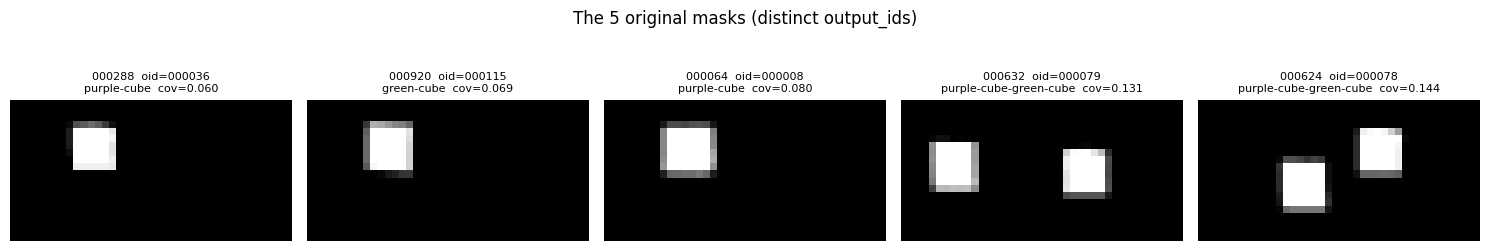

In [3]:
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(3 * N_SAMPLES, 2.4))
for ax, r in zip(axes, picks):
    ax.imshow(r['mask'], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"{r['name']}  oid={r['output_id']}\n{r['layout']}  cov={r['cov']:.3f}",
                 fontsize=8)
    ax.axis('off')
fig.suptitle('The 5 original masks (distinct output_ids)', y=1.10)
plt.tight_layout()
plt.show()

## 1. Helper: apply `noisy_blur` to every sample

`noisy_blur` takes `(B, H, W)` and is stochastic, drawing from torch's **global** RNG. We
seed before each sweep row so the comparison between parameter settings is apples-to-apples
(same underlying random draws), not confounded by RNG luck.

In [4]:
def apply(masks, seed=SEED, **params):
    """Run noisy_blur on each mask with the given params. Reseeds first so different
    parameter settings are compared under the same random stream."""
    torch.manual_seed(seed)
    out = []
    for m in masks:
        t = torch.from_numpy(m).unsqueeze(0)  # (1,H,W)
        out.append(noisy_blur(t, **params).squeeze(0).numpy())
    return out


def stats(masks_aug, masks_orig):
    """Summary stats, split by whether the pixel was nonzero in the ORIGINAL mask."""
    a = np.concatenate([x.ravel() for x in masks_aug])
    o = np.concatenate([x.ravel() for x in masks_orig])
    nz = o > 0
    return dict(
        obj_mean=a[nz].mean(), obj_std=a[nz].std(),
        bg_mean=a[~nz].mean(), bg_std=a[~nz].std(),
    )


ORIGINALS = [m for _, m in SAMPLES]
NAMES = [n for n, _ in SAMPLES]

## 2. Default parameters

The current defaults, on all 5 samples. Top row is the original, bottom is augmented.

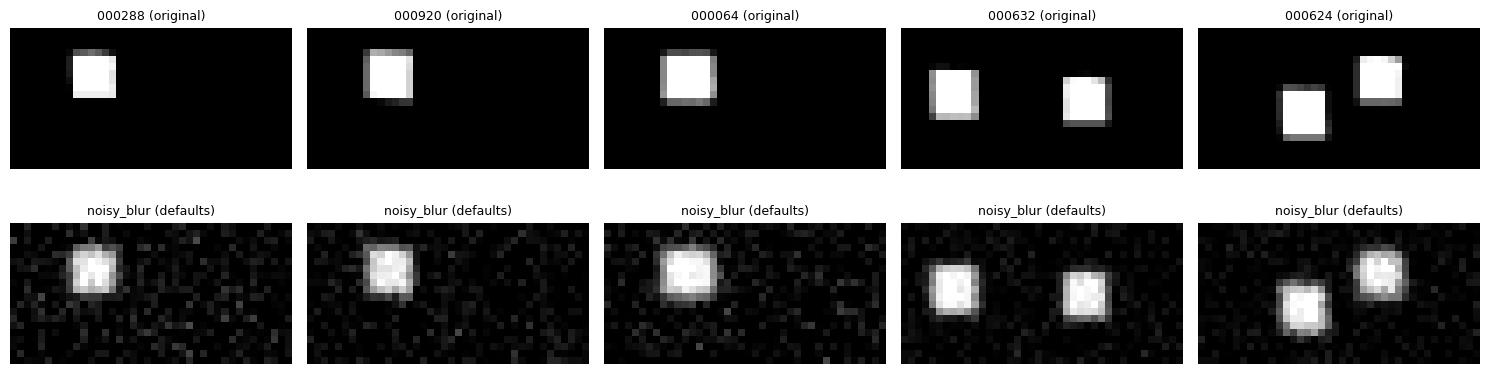

object px : mean=0.681 std=0.275
backgrd px: mean=0.032 std=0.049


In [5]:
DEFAULTS = dict(blur_noise=(0.5, 1.0), object_noise=(0.05, 0.1),
                background_noise=(0.05, 0.1))

aug = apply(ORIGINALS, **DEFAULTS)

fig, axes = plt.subplots(2, N_SAMPLES, figsize=(3 * N_SAMPLES, 4.4))
for j, (name, orig, a) in enumerate(zip(NAMES, ORIGINALS, aug)):
    axes[0, j].imshow(orig, cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(f'{name} (original)', fontsize=9)
    axes[1, j].imshow(a, cmap='gray', vmin=0, vmax=1)
    axes[1, j].set_title('noisy_blur (defaults)', fontsize=9)
    for i in (0, 1):
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

s = stats(aug, ORIGINALS)
print(f"object px : mean={s['obj_mean']:.3f} std={s['obj_std']:.3f}")
print(f"backgrd px: mean={s['bg_mean']:.3f} std={s['bg_std']:.3f}")

## 3. Sweep the *realized* noise value

Sweeping a range with `lo != hi` does not show you what a setting looks like: each panel
would draw its own hidden value from `U(lo, hi)`, so you'd see one unlabeled sample from a
distribution rather than the setting itself. You can't pick a range from that.

So every sweep below uses a **degenerate range `(v, v)`**, which pins the draw to exactly
`v`. The row label is therefore the *actual* sigma / noise std applied.

Each sweep also **zeroes the other two noise sources**, so a figure shows one effect and
nothing else. Section 4 then widens the ranges to show the per-sample variation around
whichever center you pick here.

In [6]:
# every source off; sweeps switch exactly one back on, with std=0 so the value is exact
# sigma divides inside the gaussian kernel, so sigma=0 is NaN, not "no blur". MIN_SIGMA is
# small enough that the radius-1 kernel is the identity to float precision.
MIN_SIGMA = 0.05
OFF = dict(blur_noise=(MIN_SIGMA, MIN_SIGMA), object_noise=(0.0, 0.0),
           background_noise=(0.0, 0.0))


def sweep_value(param, values, samples=ORIGINALS, names=NAMES, seed=SEED, title=None):
    """One row per REALIZED value of `param`: the range is pinned to (v, v) and every
    other noise source is off, so the row label is exactly what was applied."""
    rows = [apply(samples, seed=seed, **{**OFF, param: (v, v)}) for v in values]
    assert not any(np.isnan(a).any() for row in rows for a in row), 'NaN in sweep output'

    n = len(samples)
    fig, axes = plt.subplots(len(values), n, figsize=(2.6 * n, 1.75 * len(values)),
                             squeeze=False)
    for i, (v, row) in enumerate(zip(values, rows)):
        for j, a in enumerate(row):
            axes[i, j].imshow(a, cmap='gray', vmin=0, vmax=1)
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(names[j], fontsize=9)
        axes[i, 0].text(-0.12, 0.5, f'{v:g}', transform=axes[i, 0].transAxes,
                        ha='right', va='center', fontsize=11, family='monospace')
    fig.suptitle(title or f'{param}: realized value (all other noise off)', y=1.005)
    plt.tight_layout()
    plt.show()

    print(f'{"value":>8} | {"obj mean":>9} {"obj std":>8} | {"bg mean":>8} {"bg std":>7}')
    for v, row in zip(values, rows):
        s = stats(row, samples)
        print(f'{v:>8g} | {s["obj_mean"]:9.3f} {s["obj_std"]:8.3f} | '
              f'{s["bg_mean"]:8.3f} {s["bg_std"]:7.3f}')
    return rows

### Figure 1 — blur sigma

Pure blur: no object or background noise at all. Each row is the exact sigma applied to the
3x3 Gaussian kernel. Watch where the edge softening stops changing — the kernel has radius 1,
so once it is near-uniform, larger sigma buys nothing, and any `blur_noise` past that point
is wasted.

Note the first row is `sigma=0.05`, not 0: sigma divides inside the Gaussian kernel, so 0
would be NaN rather than "no blur". At that size the radius-1 kernel is already the identity,
so it reads as unblurred.

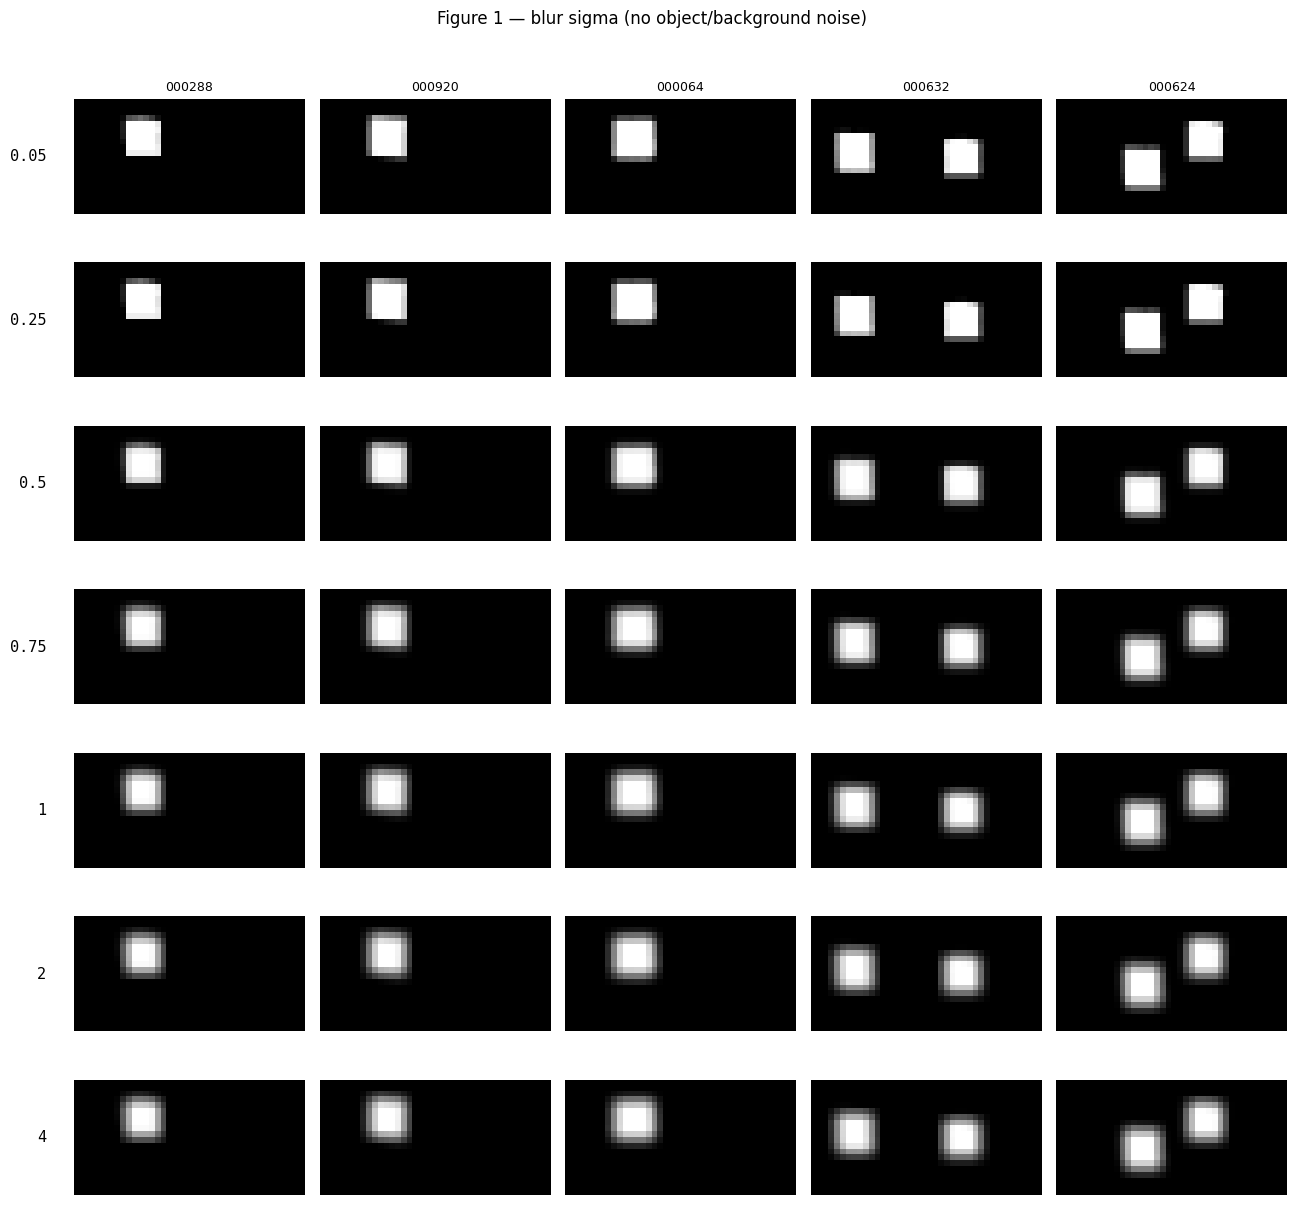

   value |  obj mean  obj std |  bg mean  bg std
    0.05 |     0.743    0.345 |    0.000   0.000
    0.25 |     0.743    0.345 |    0.000   0.000
     0.5 |     0.719    0.308 |    0.003   0.013
    0.75 |     0.693    0.277 |    0.005   0.026
       1 |     0.683    0.268 |    0.006   0.031
       2 |     0.673    0.262 |    0.007   0.036
       4 |     0.671    0.260 |    0.008   0.037


In [7]:
_ = sweep_value('blur_noise', [MIN_SIGMA, 0.25, 0.5, 0.75, 1.0, 2.0, 4.0],
                title='Figure 1 — blur sigma (no object/background noise)')

### Figure 2 — object noise std

Noise applied only to pixels that were nonzero in the original mask. No blur, no background
noise. Each row is the exact std of the Gaussian noise added. Look for where the object stops
reading as a solid shape.

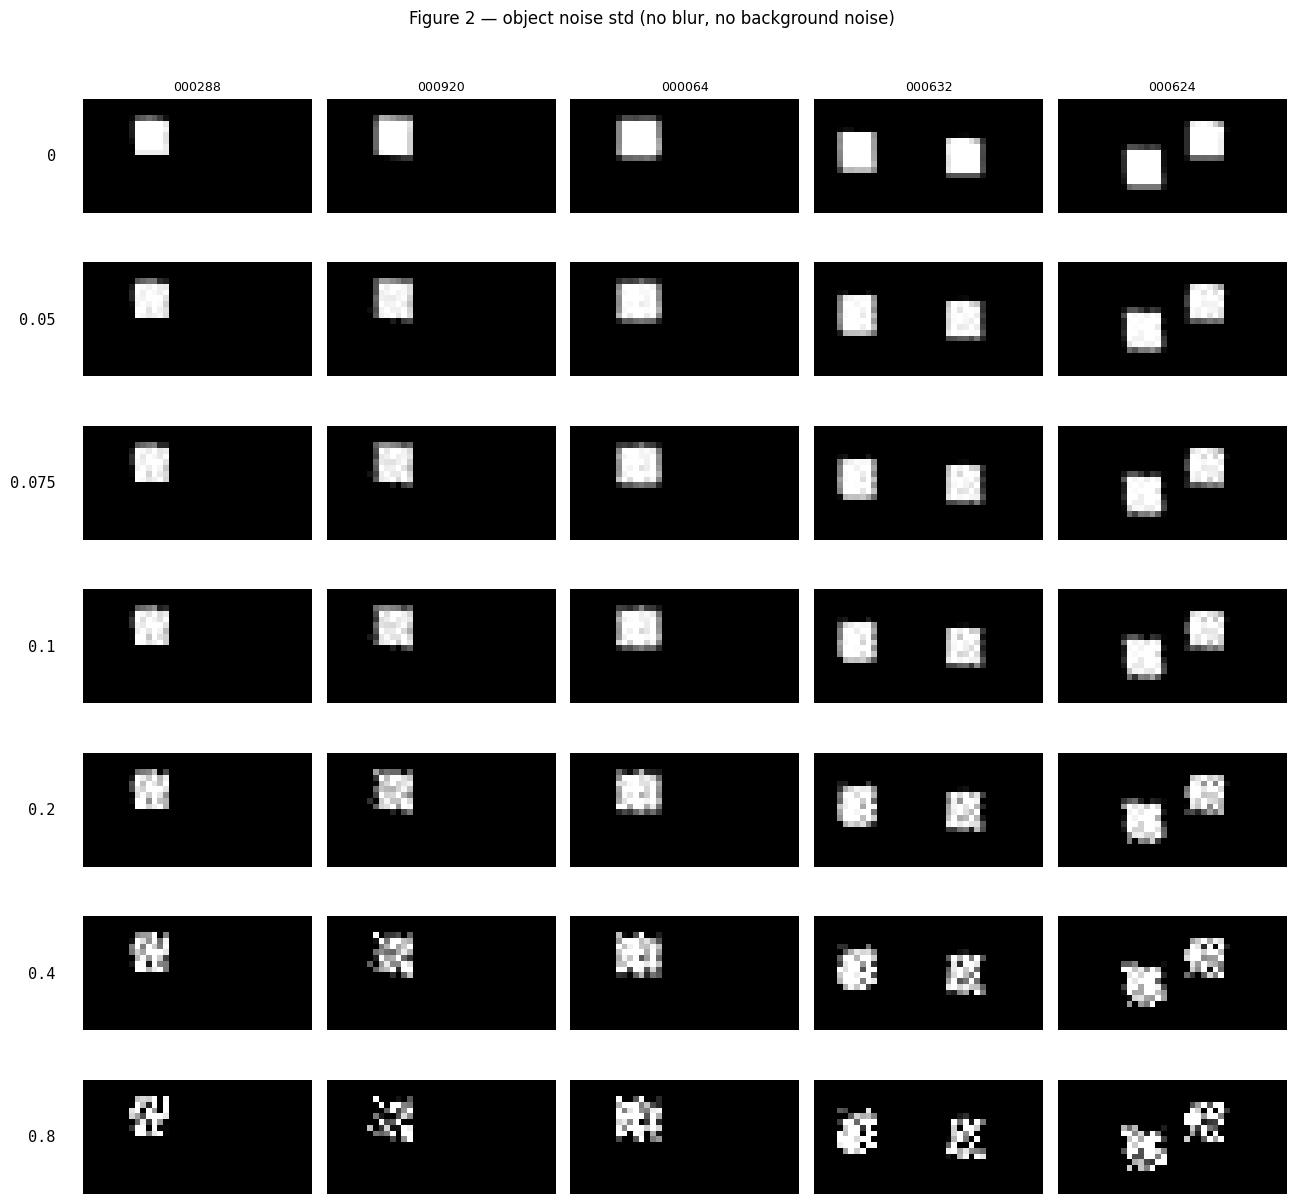

   value |  obj mean  obj std |  bg mean  bg std
       0 |     0.743    0.345 |    0.000   0.000
    0.05 |     0.728    0.338 |    0.000   0.000
   0.075 |     0.721    0.335 |    0.000   0.000
     0.1 |     0.713    0.333 |    0.000   0.000
     0.2 |     0.686    0.331 |    0.000   0.000
     0.4 |     0.638    0.353 |    0.000   0.000
     0.8 |     0.564    0.414 |    0.000   0.000


In [8]:
_ = sweep_value('object_noise', [0.0, 0.05, 0.075, 0.1, 0.2, 0.4, 0.8],
                title='Figure 2 — object noise std (no blur, no background noise)')

### Figure 3 — background noise std

Noise applied only to pixels that were zero originally. No blur, no object noise. Each row is
the exact std applied.

Because the background is exactly 0 and the output is clamped to `[0, 1]`, symmetric noise here
is **half-rectified** — only the positive half survives. So this knob brightens the background
rather than perturbing it symmetrically, and the background mean climbs with the value.

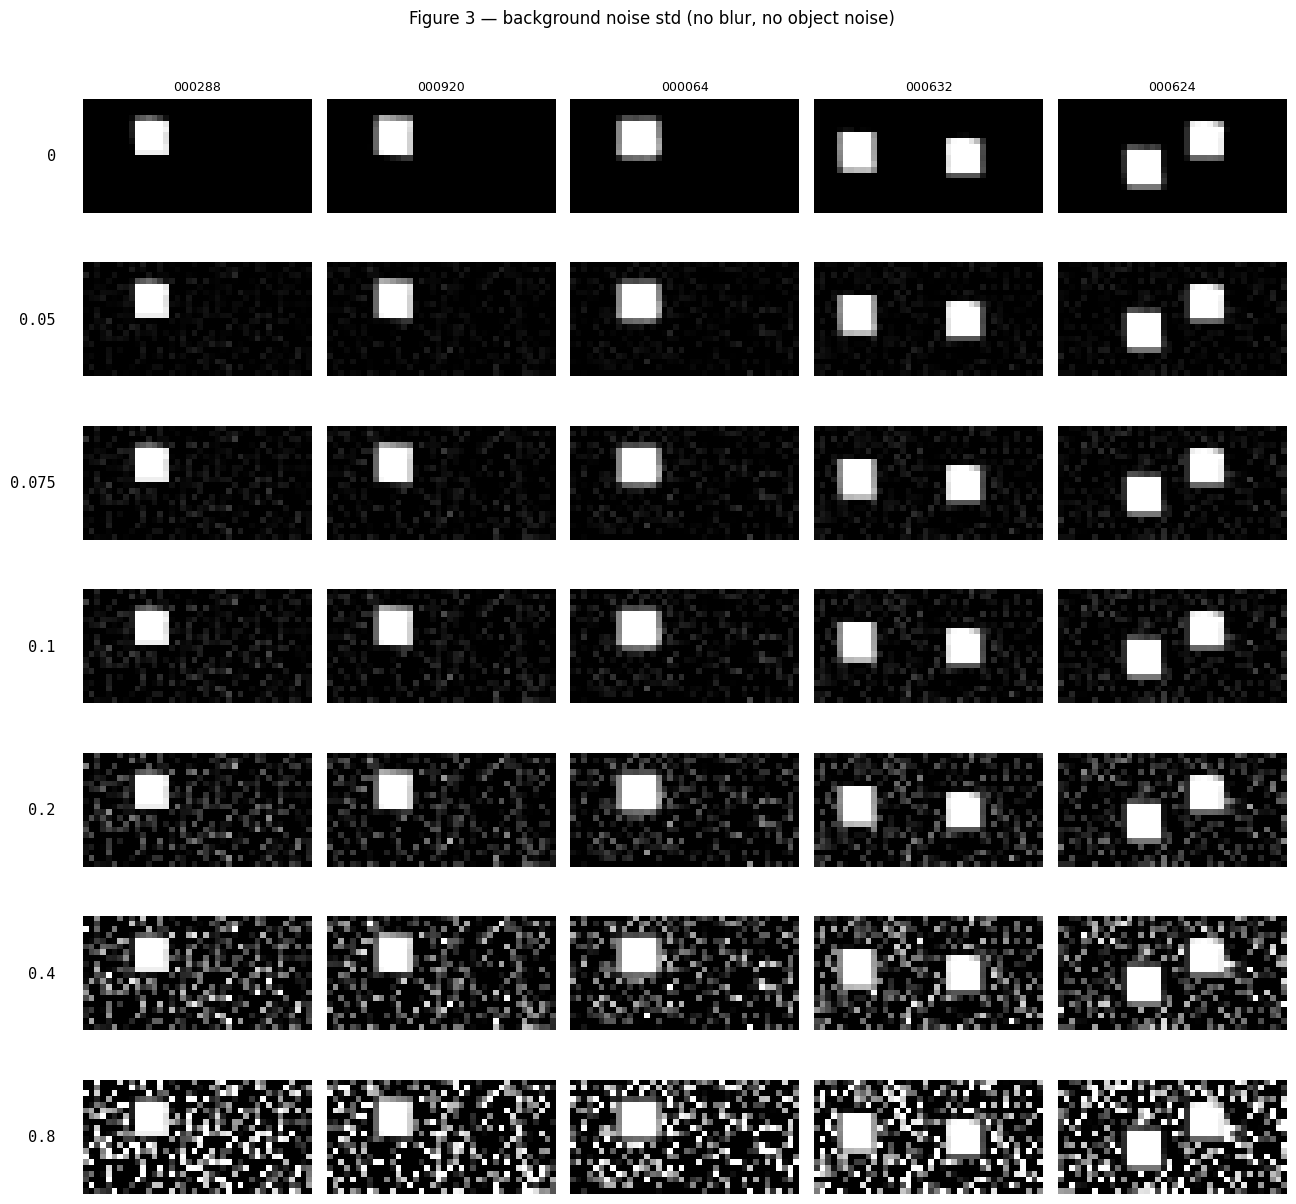

   value |  obj mean  obj std |  bg mean  bg std
       0 |     0.743    0.345 |    0.000   0.000
    0.05 |     0.743    0.345 |    0.019   0.028
   0.075 |     0.743    0.345 |    0.028   0.042
     0.1 |     0.743    0.345 |    0.038   0.057
     0.2 |     0.743    0.345 |    0.076   0.113
     0.4 |     0.743    0.345 |    0.150   0.224
     0.8 |     0.743    0.345 |    0.267   0.362


In [9]:
_ = sweep_value('background_noise', [0.0, 0.05, 0.075, 0.1, 0.2, 0.4, 0.8],
                title='Figure 3 — background noise std (no blur, no object noise)')

## 4. What the range width buys you

Section 3 pinned the value. Widening a range is the only thing that makes the realized
value vary between samples.

Below, each row is a different range and each column an independent draw on the same sample,
with the other two noise sources off. A degenerate row `(v, v)` is identical across columns;
a wide row visibly varies.

In [10]:
def sweep_spread(param, ranges, mask=None, n_draws=6, seed=SEED):
    """One row per range; each column is an independent draw on the SAME mask."""
    if mask is None:
        mask = ORIGINALS[N_SAMPLES // 2]
    t = torch.from_numpy(mask).unsqueeze(0)

    fig, axes = plt.subplots(len(ranges), n_draws, figsize=(2.0 * n_draws, 1.7 * len(ranges)),
                             squeeze=False)
    torch.manual_seed(seed)
    for i, rng in enumerate(ranges):
        params = {**OFF, param: rng}
        for j in range(n_draws):
            a = noisy_blur(t, **params).squeeze(0).numpy()
            axes[i, j].imshow(a, cmap='gray', vmin=0, vmax=1)
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(f'draw {j}', fontsize=9)
        axes[i, 0].text(-0.12, 0.5, f'{rng[0]:g}-{rng[1]:g}', transform=axes[i, 0].transAxes,
                        ha='right', va='center', fontsize=10, family='monospace')
    fig.suptitle(f'{param}: widening the range (other noise off)', y=1.005)
    plt.tight_layout()
    plt.show()

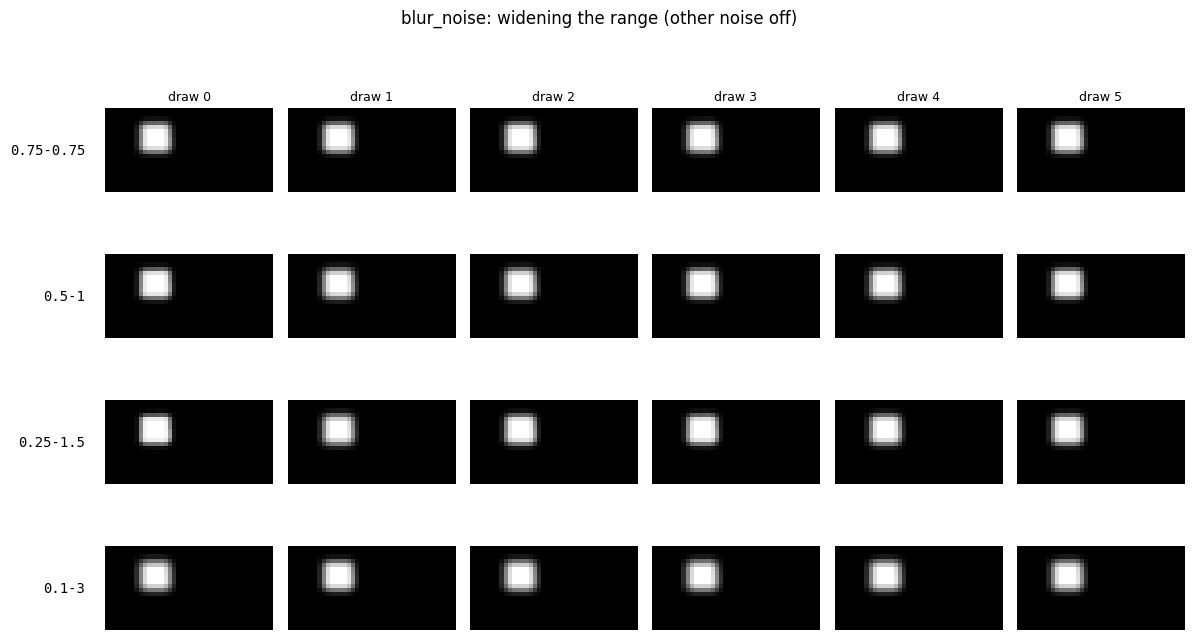

In [11]:
sweep_spread('blur_noise', [(0.75, 0.75), (0.5, 1.0), (0.25, 1.5), (0.1, 3.0)])

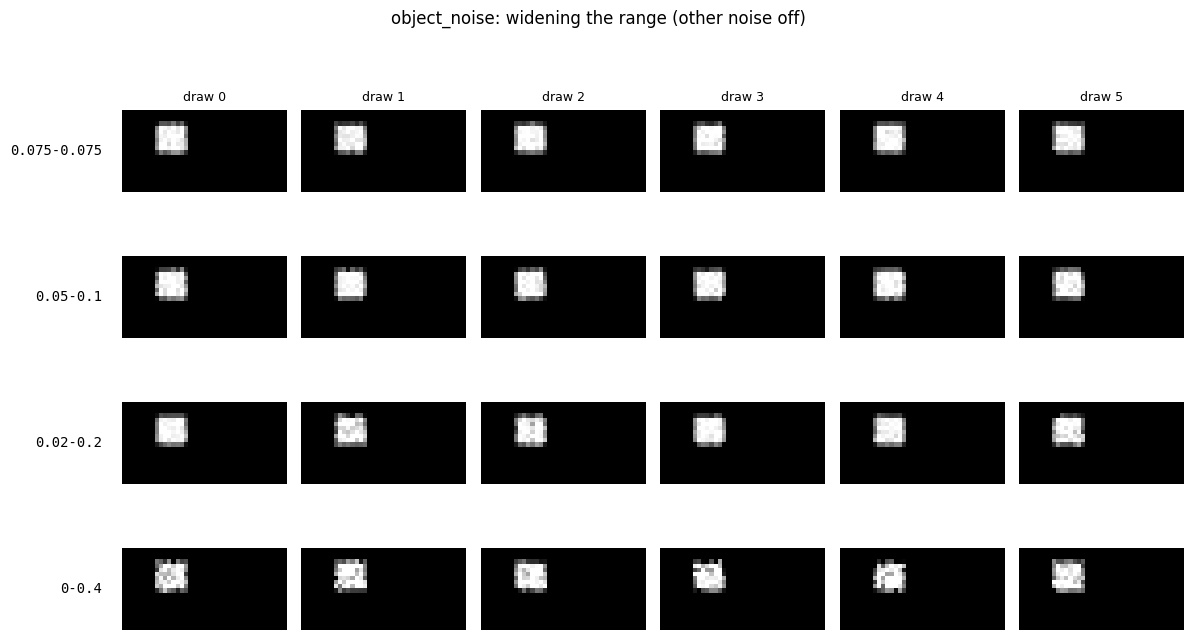

In [12]:
sweep_spread('object_noise', [(0.075, 0.075), (0.05, 0.1), (0.02, 0.2), (0.0, 0.4)])

### Distribution of the realized value

Draw many times and histogram the value that actually got applied — the distribution the
range induces, which section 3's sweeps deliberately collapse.

       blur: mean=0.7476 min=0.5000 max=0.9999 within range=True
     object: mean=0.0748 min=0.0500 max=0.1000 within range=True
 background: mean=0.0748 min=0.0500 max=0.1000 within range=True


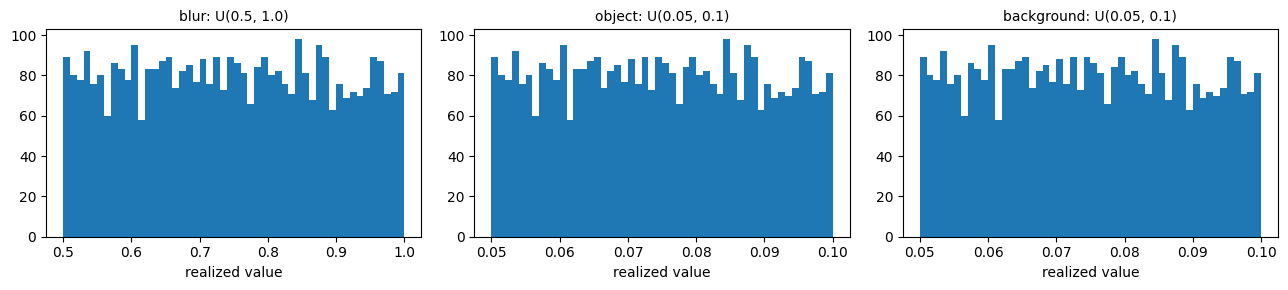

In [13]:
from model.dataset import _sample_scale

N_TRIALS = 4000
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, (label, key) in zip(axes, [('blur', 'blur_noise'), ('object', 'object_noise'),
                                   ('background', 'background_noise')]):
    lo, hi = DEFAULTS[key]
    torch.manual_seed(SEED)
    vals = np.array([_sample_scale(lo, hi).item() for _ in range(N_TRIALS)])
    ax.hist(vals, bins=50)
    ax.set_title(f'{label}: U({lo}, {hi})', fontsize=10)
    ax.set_xlabel('realized value')
    print(f'{label:>11}: mean={vals.mean():.4f} min={vals.min():.4f} max={vals.max():.4f} '
          f'within range={bool((vals >= lo).all() and (vals <= hi).all())}')
plt.tight_layout()
plt.show()

## 5. Candidate settings, side by side

A few end-to-end presets rather than one-knob-at-a-time, to judge which regime looks
usable as a training augmentation: strong enough to regularize, not so strong that the
object stops being recognizable.

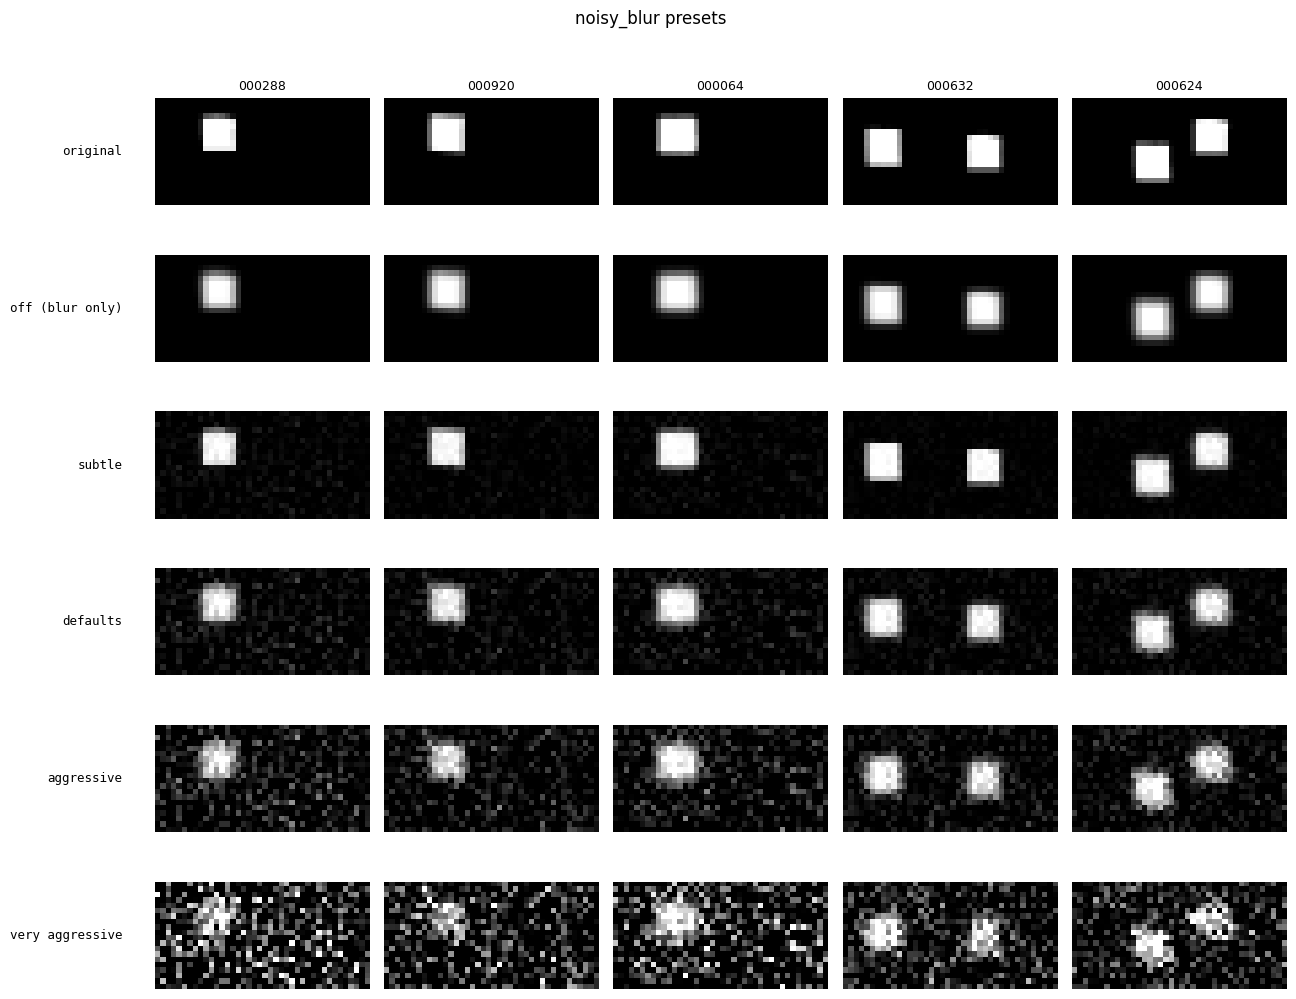

            preset |  obj mean  obj std |  bg mean  bg std
   off (blur only) |     0.697    0.279 |    0.005   0.024
            subtle |     0.721    0.315 |    0.014   0.023
          defaults |     0.681    0.275 |    0.032   0.049
        aggressive |     0.649    0.274 |    0.061   0.093
   very aggressive |     0.598    0.330 |    0.144   0.217


In [14]:
PRESETS = {
    'off (blur only)':  dict(blur_noise=(0.5, 1.0), object_noise=(0.0, 0.0),
                             background_noise=(0.0, 0.0)),
    'subtle':           dict(blur_noise=(0.3, 0.6), object_noise=(0.02, 0.05),
                             background_noise=(0.02, 0.05)),
    'defaults':         dict(DEFAULTS),
    'aggressive':       dict(blur_noise=(0.75, 1.5), object_noise=(0.1, 0.2),
                             background_noise=(0.1, 0.2)),
    'very aggressive':  dict(blur_noise=(1.0, 2.5), object_noise=(0.25, 0.5),
                             background_noise=(0.25, 0.5)),
}

fig, axes = plt.subplots(len(PRESETS) + 1, N_SAMPLES,
                         figsize=(2.6 * N_SAMPLES, 1.7 * (len(PRESETS) + 1)), squeeze=False)
for j, (name, m) in enumerate(SAMPLES):
    axes[0, j].imshow(m, cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(name, fontsize=9)
    axes[0, j].axis('off')
axes[0, 0].text(-0.15, 0.5, 'original', transform=axes[0, 0].transAxes,
                ha='right', va='center', fontsize=9, family='monospace')

for i, (label, params) in enumerate(PRESETS.items(), start=1):
    row = apply(ORIGINALS, **params)
    for j, a in enumerate(row):
        axes[i, j].imshow(a, cmap='gray', vmin=0, vmax=1)
        axes[i, j].axis('off')
    axes[i, 0].text(-0.15, 0.5, label, transform=axes[i, 0].transAxes,
                    ha='right', va='center', fontsize=9, family='monospace')
fig.suptitle('noisy_blur presets', y=1.004)
plt.tight_layout()
plt.show()

print(f'{"preset":>18} | {"obj mean":>9} {"obj std":>8} | {"bg mean":>8} {"bg std":>7}')
for label, params in PRESETS.items():
    s = stats(apply(ORIGINALS, **params), ORIGINALS)
    print(f'{label:>18} | {s["obj_mean"]:9.3f} {s["obj_std"]:8.3f} | '
          f'{s["bg_mean"]:8.3f} {s["bg_std"]:7.3f}')

## 6. Signal-to-noise: does the object stay separable?

The augmentation is only safe if a model can still tell object from background. Track the
gap between the mean object pixel and the mean background pixel as the noise grows — once
that gap collapses, the label has been destroyed.

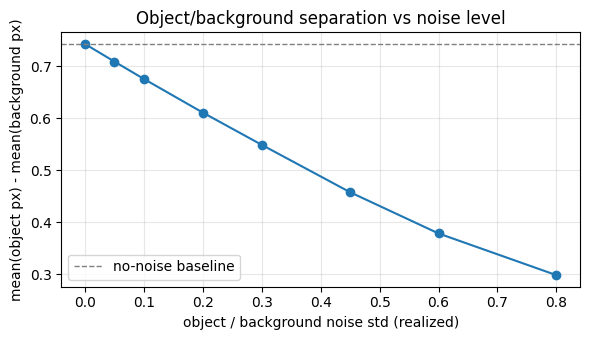

  noise=0.00  separation=0.743  (100.0% of baseline)
  noise=0.05  separation=0.709  ( 95.4% of baseline)
  noise=0.10  separation=0.676  ( 90.9% of baseline)
  noise=0.20  separation=0.611  ( 82.2% of baseline)
  noise=0.30  separation=0.549  ( 73.9% of baseline)
  noise=0.45  separation=0.457  ( 61.6% of baseline)
  noise=0.60  separation=0.378  ( 50.9% of baseline)
  noise=0.80  separation=0.298  ( 40.1% of baseline)


In [15]:
levels = [0.0, 0.05, 0.1, 0.2, 0.3, 0.45, 0.6, 0.8]
gaps = []
for lv in levels:
    # degenerate ranges + blur off, so `lv` is exactly the noise std applied
    row = apply(ORIGINALS, **{**OFF, 'object_noise': (lv, lv), 'background_noise': (lv, lv)})
    s = stats(row, ORIGINALS)
    gaps.append(s['obj_mean'] - s['bg_mean'])

plt.figure(figsize=(6, 3.5))
plt.plot(levels, gaps, marker='o')
plt.axhline(gaps[0], ls='--', c='gray', lw=1, label='no-noise baseline')
plt.xlabel('object / background noise std (realized)')
plt.ylabel('mean(object px) - mean(background px)')
plt.title('Object/background separation vs noise level')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for lv, g in zip(levels, gaps):
    print(f'  noise={lv:.2f}  separation={g:.3f}  ({g / gaps[0] * 100:5.1f}% of baseline)')